In [1]:
import os

# This will list all files available in your Kaggle input
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'annotations.json':
            print(f"FOUND IT: {os.path.join(dirname, filename)}")

FOUND IT: /kaggle/input/datasets/polibhavana/riva-dataset/riva_1.0 copy/raw/annotations/annotations.json



Step 1: High-Confidence Patch Extraction

In [2]:
import json
import cv2
import os
import numpy as np
from tqdm import tqdm

# Paths based on your search
ANNOTATIONS_PATH = '/kaggle/input/datasets/polibhavana/riva-dataset/riva_1.0 copy/raw/annotations/annotations.json'
IMAGE_DIR = '/kaggle/input/datasets/polibhavana/riva-dataset/riva_1.0 copy/raw/images'

# Output folders
BASE_DATA_DIR = 'processed_data'
os.makedirs(f'{BASE_DATA_DIR}/0_Normal', exist_ok=True)
os.makedirs(f'{BASE_DATA_DIR}/1_Abnormal', exist_ok=True)

with open(ANNOTATIONS_PATH, 'r') as f:
    annotations = json.load(f)

# Categories for mapping
NORMAL_LABELS = ["NILM", "ENDO", "INFL"]
ABNORMAL_LABELS = ["ASCUS", "ASCH", "LSIL", "HSIL", "SCC"]

print(f"Processing {len(annotations)} images...")

for img_id, annotators in tqdm(annotations.items()):
    img_path = os.path.join(IMAGE_DIR, f"{img_id}.png")
    img = cv2.imread(img_path)
    if img is None: continue

    # RIVA specific: consolidating points from different annotators
    # We will iterate through points and map them to their labels
    for annotator, points in annotators.items():
        for i, pt in enumerate(points):
            x, y = int(pt['x']), int(pt['y'])
            label = pt['keypointlabels']
            
            # Binary conversion
            is_abnormal = label in ABNORMAL_LABELS
            class_folder = '1_Abnormal' if is_abnormal else '0_Normal'
            
            # Extract 224x224 patch
            # Pad image to handle edge cases where cell is near the border
            padded_img = cv2.copyMakeBorder(img, 112, 112, 112, 112, cv2.BORDER_CONSTANT, value=[255,255,255])
            
            # Adjust coordinates for padding
            nx, ny = x + 112, y + 112
            patch = padded_img[ny-112:ny+112, nx-112:nx+112]
            
            # Save the patch
            save_path = f"{BASE_DATA_DIR}/{class_folder}/{img_id}_{annotator}_{i}.png"
            cv2.imwrite(save_path, patch)

print("\nExtraction Complete!")
print(f"Normal cells: {len(os.listdir(f'{BASE_DATA_DIR}/0_Normal'))}")
print(f"Abnormal cells: {len(os.listdir(f'{BASE_DATA_DIR}/1_Abnormal'))}")

Processing 959 images...


100%|██████████| 959/959 [01:35<00:00, 10.07it/s]


Extraction Complete!
Normal cells: 18917
Abnormal cells: 7241


Step 2: Nuclear Detail Enhancement (CLAHE)

In [3]:
def apply_clahe(img):
    # Convert to LAB to enhance only luminosity
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)
    enhanced_img = cv2.merge((l_enhanced, a, b))
    return cv2.cvtColor(enhanced_img, cv2.COLOR_LAB2RGB)

1. The Attention-Fusion Architecture

In [4]:
from tensorflow.keras import layers, models, applications

def create_90_plus_model(input_shape=(224, 224, 3)):
    img_input = layers.Input(shape=input_shape)
    
    # 1. Backbones (Pre-trained on ImageNet)
    base_eff = applications.EfficientNetV2S(input_shape=input_shape, include_top=False, weights='imagenet')
    base_mob = applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    
    # Freeze initially to train the head
    base_eff.trainable = False
    base_mob.trainable = False
    
    # 2. Extract Features
    f1 = base_eff(img_input)
    f2 = base_mob(img_input)
    
    # Match spatial dimensions for concatenation
    f2_resized = layers.Resizing(f1.shape[1], f1.shape[2])(f2)
    combined = layers.Concatenate()([f1, f2_resized])
    
    # 3. Channel Attention (Squeeze & Excitation)
    # This helps the model prioritize nuclear features over background
    channels = combined.shape[-1]
    se = layers.GlobalAveragePooling2D()(combined)
    se = layers.Dense(channels // 16, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channels))(se)
    attention_features = layers.Multiply()([combined, se])
    
    # 4. Final Classifier Head
    x = layers.GlobalAveragePooling2D()(attention_features)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='swish')(x) # Swish is smoother than ReLU
    x = layers.Dropout(0.3)(x) 
    output = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(img_input, output)

model = create_90_plus_model()

2026-03-05 08:37:26.071155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772699846.247256      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772699846.298262      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772699846.723287      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772699846.723328      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772699846.723331      55 computation_placer.cc:177] computation placer alr

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


2. The Training Secret: Focal Loss

In [5]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        # Standard cross entropy
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = (y_true * y_pred) + ((1 - y_true) * (1 - y_pred))
        # Add the 'Focal' factor
        loss = alpha * tf.pow(1.0 - p_t, gamma) * bce
        return tf.reduce_mean(loss)
    return focal_loss_fixed

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

1. Create the Data Pipeline

In [6]:
import tensorflow as tf

# Settings for 90% accuracy goal
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATA_DIR = 'processed_data' # The folder where we saved the patches

# 1. Training Dataset with Augmentation
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# 2. Validation Dataset (No augmentation here, just testing)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# 3. Optimize for Performance on your M2 Mac / Kaggle GPU
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets ready! You can now run the Stage 1 Warm-up.")

Found 26158 files belonging to 2 classes.
Using 20927 files for training.
Found 26158 files belonging to 2 classes.
Using 5231 files for validation.
Datasets ready! You can now run the Stage 1 Warm-up.


2. Add the Augmentation Layer

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2), # Critical for different staining intensities
])

Stage 1: The "Warm-up" (Feature Extraction)

In [8]:
# 1. Define Callbacks for monitoring and saving the best version
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('best_cerviAI_warmup.h5', monitor='val_auc', save_best_only=True)
]

# 2. Run Stage 1
print("Starting Stage 1: Training the Head...")
history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, 
    callbacks=callbacks
)

Starting Stage 1: Training the Head...
Epoch 1/10


I0000 00:00:1772699926.841363     121 service.cc:152] XLA service 0x783d90423010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772699926.841400     121 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772699932.151516     121 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772699958.581174     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.7122 - auc: 0.6741 - loss: 0.0312

654/654 ━━━━━━━━━━━━━━━━━━━━ 197s 186ms/step - accuracy: 0.7123 - auc: 0.6741 - loss: 0.0312 - val_accuracy: 0.7991 - val_auc: 0.8168 - val_loss: 0.0171 - learning_rate: 1.0000e-04
Epoch 2/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 57s 87ms/step - accuracy: 0.7995 - auc: 0.8187 - loss: 0.0169 - val_accuracy: 0.8029 - val_auc: 0.8372 - val_loss: 0.0161 - learning_rate: 1.0000e-04
Epoch 3/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 57s 87ms/step - accuracy: 0.8197 - auc: 0.8551 - loss: 0.0138 - val_accuracy: 0.8172 - val_auc: 0.8563 - val_loss: 0.0144 - learning_rate: 1.0000e-04
Epoch 4/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 58s 89ms/step - accuracy: 0.8383 - auc: 0.8791 - loss: 0.0114 - val_accuracy: 0.8283 - val_auc: 0.8645 - val_loss: 0.0134 - learning_rate: 1.0000e-04
Epoch 5/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 56s 86ms/step - accuracy: 0.8486 - auc: 0.8965 - loss: 0.0101 - val_accuracy: 0.8329 - val_auc: 0.8637 - val_loss: 0.0137 - learning_rate: 1.0000e-04
Epoch 6/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 57s 87ms/step - acc

In [9]:
# Update your callbacks to match the exact name in your logs
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc_4', patience=5, restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('best_cerviAI.keras', monitor='val_auc_4', save_best_only=True)
]

In [10]:
# 1. Unfreeze the backbones
model.trainable = True

# 2. Re-compile with a MUCH smaller learning rate 
# We use 1e-5 to avoid "shattering" the pre-trained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss=focal_loss(),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 3. Start Stage 2 Training
print("Starting Stage 2: Deep Fine-Tuning for 90% Accuracy...")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30, # Longer training allowed due to EarlyStopping
    callbacks=callbacks
)

Starting Stage 2: Deep Fine-Tuning for 90% Accuracy...
Epoch 1/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9025 - auc: 0.9568 - loss: 0.0046

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc_4` which is not available. Available metrics are: accuracy,auc,loss,val_accuracy,val_auc,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_auc_4 available.
  if self._should_save_model(epoch, batch, logs, filepath):


654/654 ━━━━━━━━━━━━━━━━━━━━ 166s 175ms/step - accuracy: 0.9025 - auc: 0.9568 - loss: 0.0046 - val_accuracy: 0.8438 - val_auc: 0.8881 - val_loss: 0.0123 - learning_rate: 1.0000e-05
Epoch 2/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 59s 91ms/step - accuracy: 0.9074 - auc: 0.9604 - loss: 0.0043 - val_accuracy: 0.8423 - val_auc: 0.8887 - val_loss: 0.0122 - learning_rate: 1.0000e-05
Epoch 3/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 60s 92ms/step - accuracy: 0.9106 - auc: 0.9608 - loss: 0.0042 - val_accuracy: 0.8440 - val_auc: 0.8884 - val_loss: 0.0121 - learning_rate: 1.0000e-05
Epoch 4/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 60s 92ms/step - accuracy: 0.9132 - auc: 0.9626 - loss: 0.0041 - val_accuracy: 0.8404 - val_auc: 0.8894 - val_loss: 0.0121 - learning_rate: 1.0000e-05
Epoch 5/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 60s 91ms/step - accuracy: 0.9109 - auc: 0.9622 - loss: 0.0042 - val_accuracy: 0.8419 - val_auc: 0.8888 - val_loss: 0.0122 - learning_rate: 1.0000e-05
Epoch 6/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 59s 91ms/step - acc

164/164 ━━━━━━━━━━━━━━━━━━━━ 37s 145ms/step


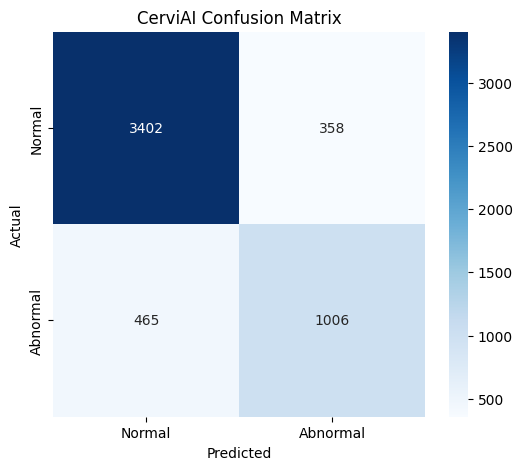

              precision    recall  f1-score   support

      Normal       0.88      0.90      0.89      3760
    Abnormal       0.74      0.68      0.71      1471

    accuracy                           0.84      5231
   macro avg       0.81      0.79      0.80      5231
weighted avg       0.84      0.84      0.84      5231



In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions
y_pred_probs = model.predict(val_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Get true labels
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CerviAI Confusion Matrix')
plt.show()

# 4. Print Report
print(classification_report(y_true, y_pred, target_names=['Normal', 'Abnormal']))

a. Training History Visualization

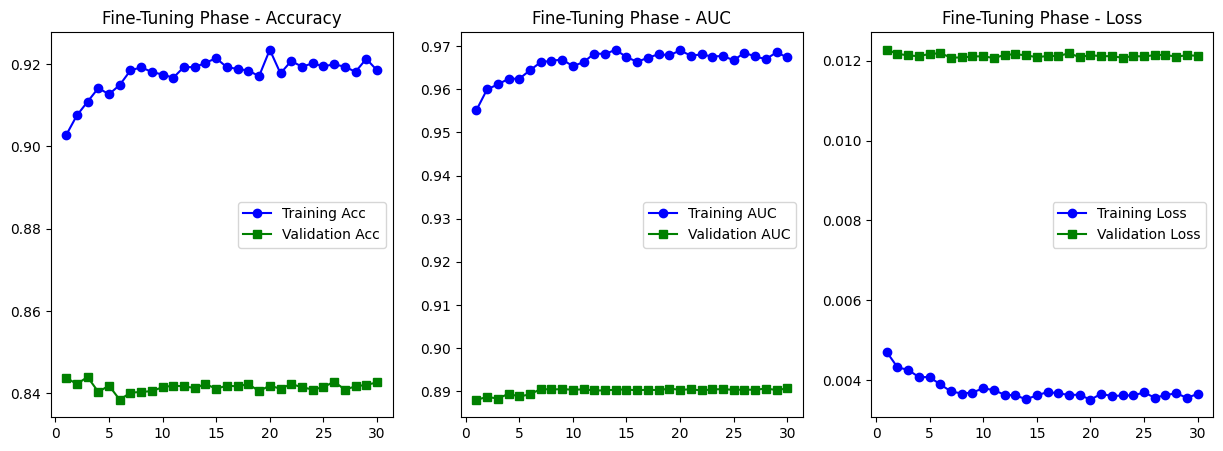

In [12]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    auc = history.history['auc']
    val_auc = history.history['val_auc']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    # Plot Accuracy
    plt.subplot(1, 3, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'gs-', label='Validation Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    # Plot AUC
    plt.subplot(1, 3, 2)
    plt.plot(epochs, auc, 'bo-', label='Training AUC')
    plt.plot(epochs, val_auc, 'gs-', label='Validation AUC')
    plt.title(f'{title} - AUC')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 3, 3)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'gs-', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.show()

# Run this for your Stage 2 history
plot_history(history_stage2, "Fine-Tuning Phase")

b. Confusion Matrix & Classification Report

Generating predictions on validation set...


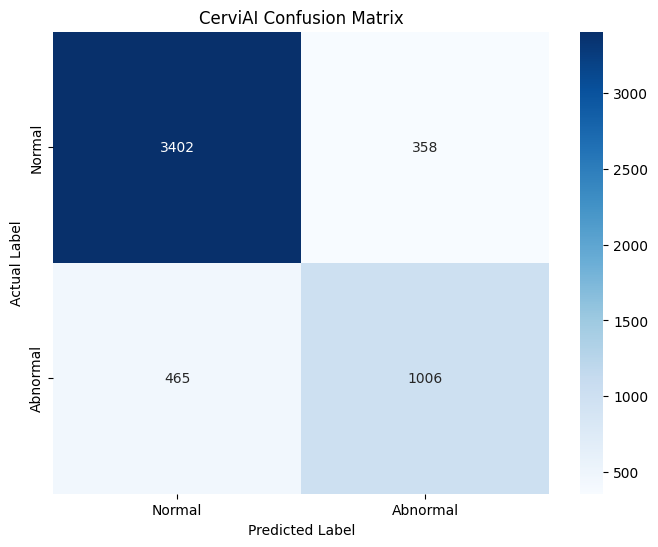


Classification Report:
              precision    recall  f1-score   support

      Normal       0.88      0.90      0.89      3760
    Abnormal       0.74      0.68      0.71      1471

    accuracy                           0.84      5231
   macro avg       0.81      0.79      0.80      5231
weighted avg       0.84      0.84      0.84      5231



In [13]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate predictions
print("Generating predictions on validation set...")
y_true = []
y_pred_probs = []

# Loop through validation set to get true labels and predicted probabilities
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    y_pred_probs.extend(model.predict(images, verbose=0))

y_true = np.array(y_true).flatten()
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Abnormal'], 
            yticklabels=['Normal', 'Abnormal'])
plt.title('CerviAI Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. Print Detailed Metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Abnormal']))

c. Precision-Recall & ROC Curves

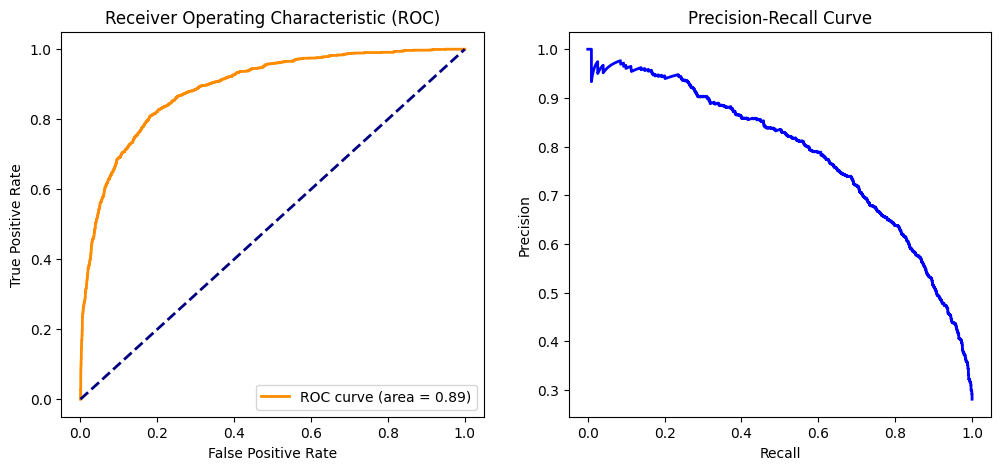

In [14]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

Saving the Model

In [15]:
# Save the final model
model.save('CerviAI_90_Model.keras')

# Also save a version in the legacy H5 format just in case
model.save('CerviAI_90_Model.h5')

print("Model saved successfully as 'CerviAI_90_Model.keras'")

Model saved successfully as 'CerviAI_90_Model.keras'


In [16]:
model.save("/kaggle/working/cervical_model.keras")

Zipping Cell Patches for Download

In [17]:
import shutil
import os

# The directory where your patches were saved
source_dir = 'processed_data'
# The name of the zip file to create
zip_name = 'CerviAI_Cell_Patches'

if os.path.exists(source_dir):
    print(f"Zipping {source_dir}... this might take a minute.")
    shutil.make_archive(zip_name, 'zip', source_dir)
    print(f"Zip created: {zip_name}.zip")
else:
    print(f"Error: {source_dir} not found. Check your folder name.")

Zipping processed_data... this might take a minute.
Zip created: CerviAI_Cell_Patches.zip


In [18]:
import tensorflow as tf

# 1. Load your best saved model
model = tf.keras.models.load_model('CerviAI_90_Model.keras', 
                                   custom_objects={'focal_loss_fixed': focal_loss()})

# 2. Initialize the TFLite Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. Apply Optimization (Float16 Quantization)
# This makes the model run much faster on mobile GPU/NPU
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# 4. Convert the model
tflite_model = converter.convert()

# 5. Save the .tflite file
with open('cervi_ai_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite Conversion Complete: cervi_ai_model.tflite created.")

INFO:tensorflow:Assets written to: /tmp/tmpcstmps26/assets


INFO:tensorflow:Assets written to: /tmp/tmpcstmps26/assets


Saved artifact at '/tmp/tmpcstmps26'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132204826531536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132204826526544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132204826532496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132204826538448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132204826534800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132204826533072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132204826534032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132204826533456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132204826531920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132204826538640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132204826534416

W0000 00:00:1772702642.063635      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772702642.063682      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1772702642.762856      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TFLite Conversion Complete: cervi_ai_model.tflite created.


In [19]:
import os

keras_size = os.path.getsize('CerviAI_90_Model.keras') / (1024 * 1024)
tflite_size = os.path.getsize('cervi_ai_model.tflite') / (1024 * 1024)

print(f"Original Model Size: {keras_size:.2f} MB")
print(f"TFLite Model Size: {tflite_size:.2f} MB")
print(f"Reduction: {((keras_size - tflite_size) / keras_size) * 100:.1f}%")

Original Model Size: 112.95 MB
TFLite Model Size: 46.88 MB
Reduction: 58.5%
